In [137]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

from sklearn.neighbors import LocalOutlierFactor

In [138]:
df = pd.read_csv("ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv")
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [139]:
print(df.shape)
df.info()
df.describe()
df.describe(include='all')

(226084, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226084 entries, 0 to 226083
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                226084 non-null  object 
 1   town                 226084 non-null  object 
 2   flat_type            226084 non-null  object 
 3   block                226084 non-null  object 
 4   street_name          226084 non-null  object 
 5   storey_range         226084 non-null  object 
 6   floor_area_sqm       226084 non-null  float64
 7   flat_model           226084 non-null  object 
 8   lease_commence_date  226084 non-null  int64  
 9   remaining_lease      226084 non-null  object 
 10  resale_price         226084 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.0+ MB


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
count,226084,226084,226084,226084,226084,226084,226084.000000,226084,226084.000000,226084,2.260840e+05
unique,110,26,7,2751,577,17,NaN,21,NaN,696,NaN
top,2024-07,SENGKANG,4 ROOM,2,YISHUN RING RD,04 TO 06,NaN,Model A,NaN,94 years 10 months,NaN
freq,3036,18447,95882,682,3223,51854,NaN,80945,NaN,1919,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,96.745685,NaN,1996.473019,NaN,5.268141e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,24.018666,NaN,14.317064,NaN,1.877925e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,NaN,1966.000000,NaN,1.400000e+05
25%,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,NaN,1985.000000,NaN,3.880000e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,1997.000000,NaN,4.950000e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN,2012.000000,NaN,6.308880e+05


In [140]:
df.isnull().sum()

month                  0
town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
dtype: int64

In [141]:
for col in ['town', 'flat_type', 'storey_range', 'flat_model']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head(10))


Column: town
town
SENGKANG         18447
PUNGGOL          16425
WOODLANDS        16064
TAMPINES         15455
YISHUN           15400
JURONG WEST      14900
BEDOK            11772
HOUGANG          11422
CHOA CHU KANG    10208
BUKIT BATOK       9448
Name: count, dtype: int64

Column: flat_type
flat_type
4 ROOM              95882
5 ROOM              55404
3 ROOM              53817
EXECUTIVE           16196
2 ROOM               4618
MULTI-GENERATION       85
1 ROOM                 82
Name: count, dtype: int64

Column: storey_range
storey_range
04 TO 06    51854
07 TO 09    47396
10 TO 12    42235
01 TO 03    39833
13 TO 15    21772
16 TO 18    10200
19 TO 21     4396
22 TO 24     3084
25 TO 27     1905
28 TO 30     1249
Name: count, dtype: int64

Column: flat_model
flat_model
Model A              80945
Improved             55209
New Generation       27636
Premium Apartment    24911
Simplified            8676
Apartment             8123
Maisonette            6206
Standard              6035


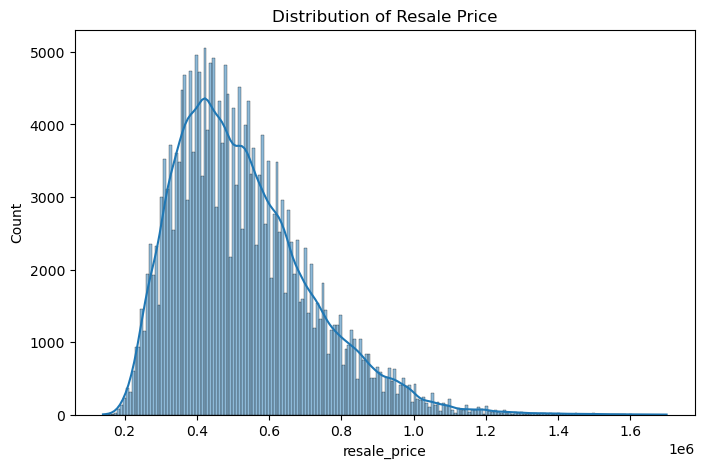

In [142]:
plt.figure(figsize=(8,5))
sns.histplot(df['resale_price'], kde=True)
plt.title('Distribution of Resale Price')
plt.show()

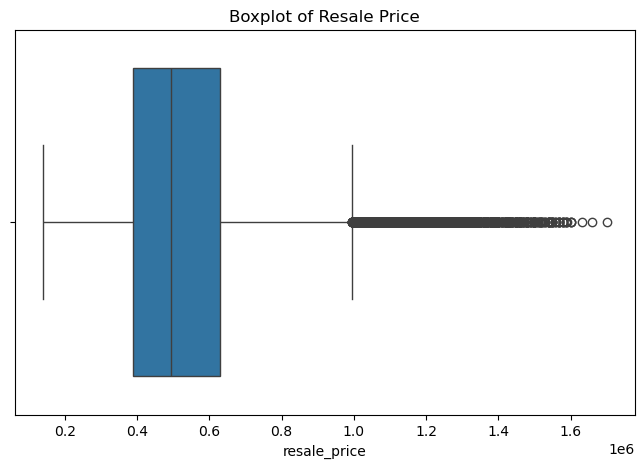

In [143]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['resale_price'])
plt.title('Boxplot of Resale Price')
plt.show()

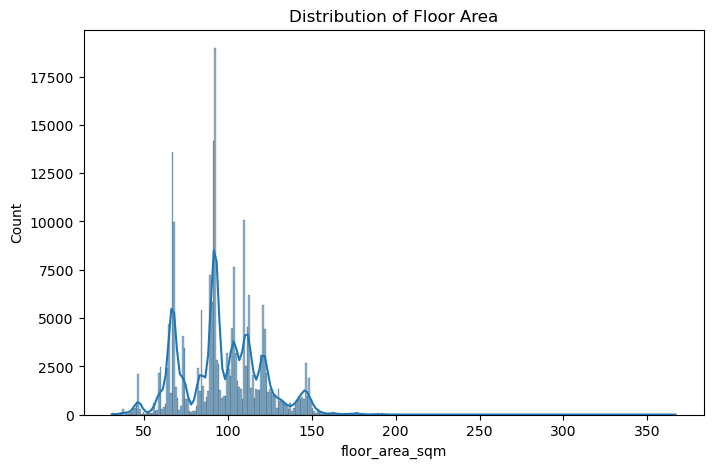

In [144]:
plt.figure(figsize=(8,5))
sns.histplot(df['floor_area_sqm'], kde=True)
plt.title('Distribution of Floor Area')
plt.show()

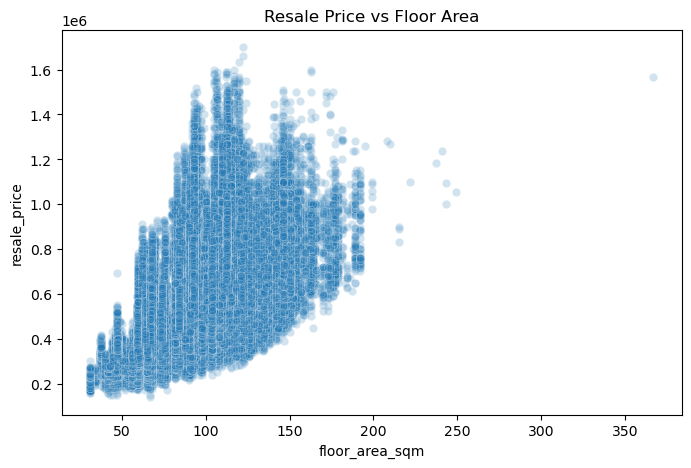

In [145]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='floor_area_sqm', y='resale_price', data=df, alpha=0.2)
plt.title('Resale Price vs Floor Area')
plt.show()

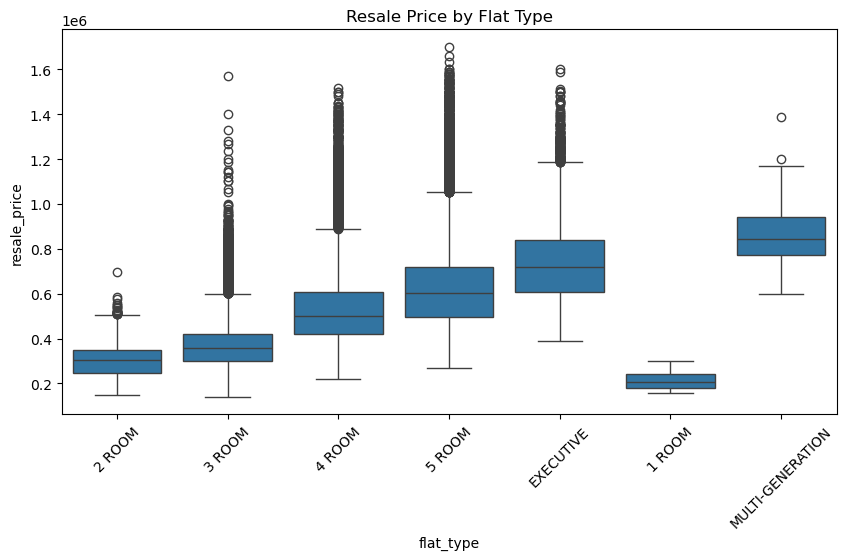

In [146]:
plt.figure(figsize=(10,5))
sns.boxplot(x='flat_type', y='resale_price', data=df)
plt.title('Resale Price by Flat Type')
plt.xticks(rotation=45)
plt.show()

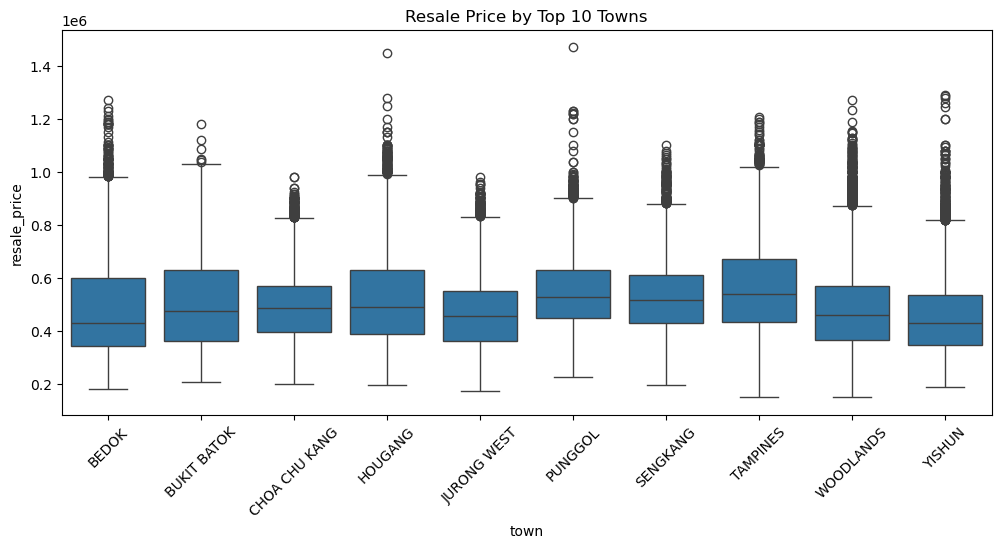

In [147]:
top_towns = df['town'].value_counts().head(10).index
plt.figure(figsize=(12,5))
sns.boxplot(x='town', y='resale_price', data=df[df['town'].isin(top_towns)])
plt.title('Resale Price by Top 10 Towns')
plt.xticks(rotation=45)
plt.show()

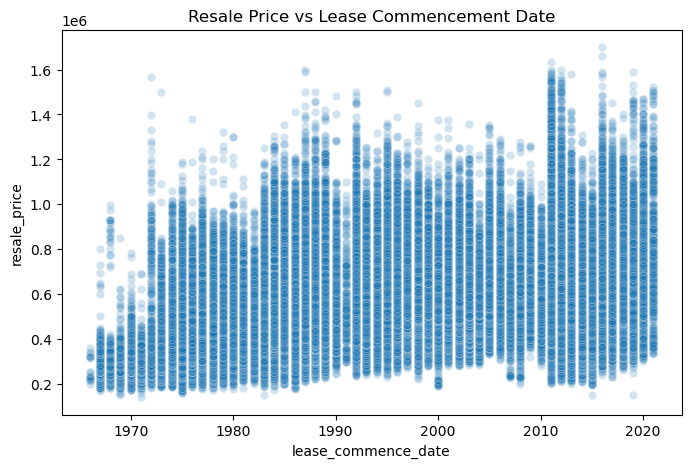

In [148]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='lease_commence_date', y='resale_price', data=df, alpha=0.2)
plt.title('Resale Price vs Lease Commencement Date')
plt.show()

In [149]:
X = df[['floor_area_sqm']]
y = df['resale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Train R^2:", r2_score(y_train, y_train_pred))
print("Test R^2:", r2_score(y_test, y_test_pred))
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Coefficient: 4452.811853914561
Intercept: 95532.83502031432
Train R^2: 0.3255961659841802
Test R^2: 0.32330997578821585
Train MSE: 23698611150.62771
Test MSE: 24116662685.519524


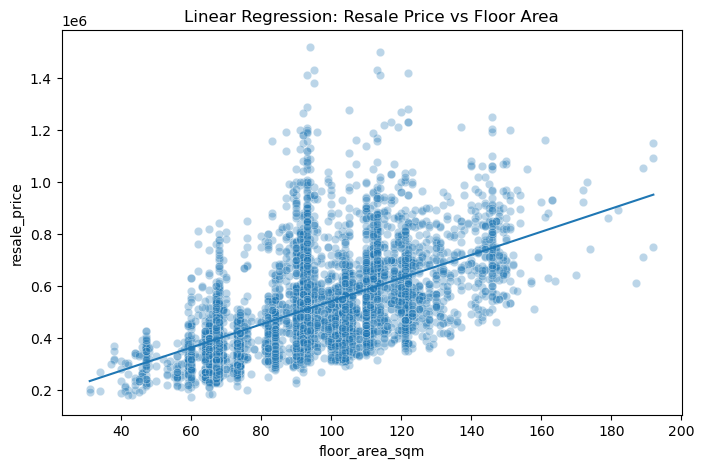

In [150]:
sample_df = df.sample(5000, random_state=42)

plt.figure(figsize=(8,5))
sns.scatterplot(x='floor_area_sqm', y='resale_price', data=sample_df, alpha=0.3)

x_line = pd.DataFrame({'floor_area_sqm': sorted(sample_df['floor_area_sqm'])})
y_line = model.predict(x_line)

plt.plot(x_line['floor_area_sqm'], y_line)
plt.title('Linear Regression: Resale Price vs Floor Area')
plt.show()

In [151]:
X = df[['lease_commence_date']]
y = df['resale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
print("Train R^2:", r2_score(y_train, y_train_pred))
print("Test R^2:", r2_score(y_test, y_test_pred))
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Coefficient: 4885.078334332134
Intercept: -9226613.603987541
Train R^2: 0.13926348891873175
Test R^2: 0.13416456806826194
Train MSE: 30246358117.21148
Test MSE: 30857645754.998844


In [152]:
df_reg = df[['resale_price', 'floor_area_sqm', 'lease_commence_date', 'flat_type', 'town']].copy()
df_reg = pd.get_dummies(df_reg, columns=['flat_type', 'town'], drop_first=True)

X = df_reg.drop('resale_price', axis=1)
y = df_reg['resale_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Train R^2:", r2_score(y_train, y_train_pred))
print("Test R^2:", r2_score(y_test, y_test_pred))
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Train R^2: 0.689200538974543
Test R^2: 0.6883740038128958
Train MSE: 10921520906.558485
Test MSE: 11106088112.998827


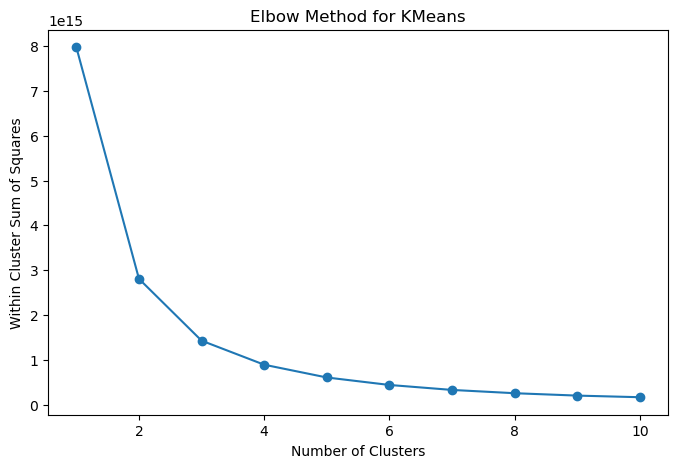

In [153]:
cluster_df = df[['floor_area_sqm', 'resale_price']].copy()

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for KMeans')
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.show()

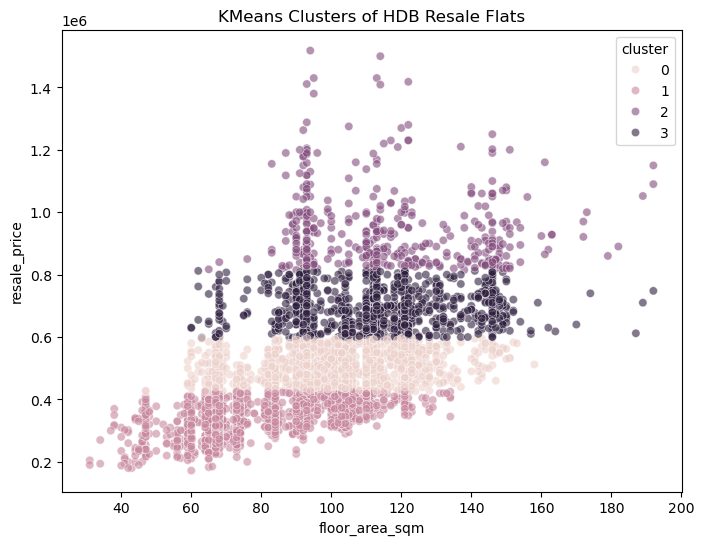

Cluster centres:
[[9.98131326e+01 5.05980015e+05]
 [7.92295167e+01 3.44984258e+05]
 [1.17648289e+02 9.42198094e+05]
 [1.11035860e+02 6.84021507e+05]]


In [154]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(cluster_df)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x='floor_area_sqm',
    y='resale_price',
    hue='cluster',
    data=cluster_df.sample(5000, random_state=42),
    alpha=0.6
)
plt.title('KMeans Clusters of HDB Resale Flats')
plt.show()

print("Cluster centres:")
print(kmeans.cluster_centers_)

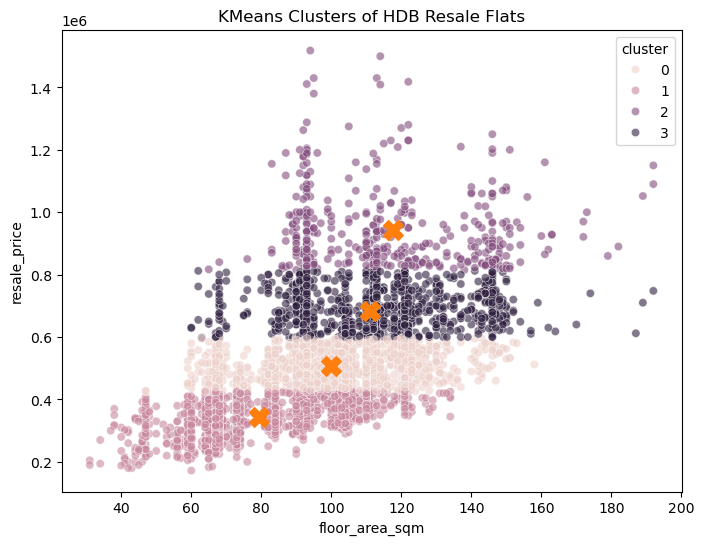

In [155]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='floor_area_sqm',
    y='resale_price',
    hue='cluster',
    data=cluster_df.sample(5000, random_state=42),
    alpha=0.6
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker='X',
    s=200
)

plt.title('KMeans Clusters of HDB Resale Flats')
plt.show()

In [156]:
anomaly_df = df[['floor_area_sqm', 'resale_price']].copy()

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
anomaly_labels = lof.fit_predict(anomaly_df)

anomaly_df['anomaly'] = anomaly_labels
print(anomaly_df['anomaly'].value_counts())

anomaly
 1    221564
-1      4520
Name: count, dtype: int64


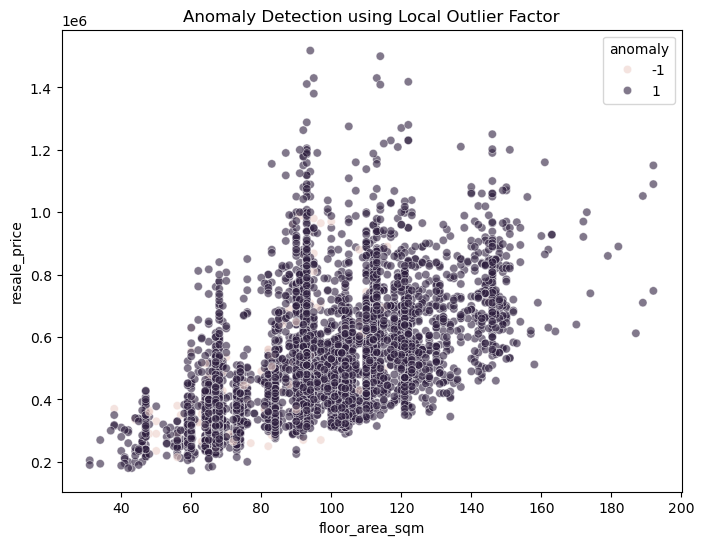

In [157]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='floor_area_sqm',
    y='resale_price',
    hue='anomaly',
    data=anomaly_df.sample(5000, random_state=42),
    alpha=0.6
)
plt.title('Anomaly Detection using Local Outlier Factor')
plt.show()

In [158]:
anomalies = df[anomaly_df['anomaly'] == -1]
anomalies[['month', 'town', 'flat_type', 'floor_area_sqm', 'lease_commence_date', 'resale_price']].head(20)

,month,town,flat_type,floor_area_sqm,lease_commence_date,resale_price
47,2017-01,ANG MO KIO,4 ROOM,91.0,2011,730000.0
166,2017-01,BUKIT BATOK,3 ROOM,67.0,1984,300188.0
210,2017-01,BUKIT MERAH,3 ROOM,65.0,1976,353000.0
223,2017-01,BUKIT MERAH,4 ROOM,82.0,1975,458000.0
224,2017-01,BUKIT MERAH,4 ROOM,81.0,1975,470000.0
233,2017-01,BUKIT MERAH,4 ROOM,95.0,2013,648000.0
235,2017-01,BUKIT MERAH,4 ROOM,95.0,2013,688000.0
241,2017-01,BUKIT MERAH,4 ROOM,89.0,2013,790000.0
243,2017-01,BUKIT MERAH,4 ROOM,81.0,1975,470000.0
302,2017-01,CENTRAL AREA,3 ROOM,66.0,1983,428000.0
